In [1]:
!pip install -q mlflow

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.7/49.7 kB 1.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.5/50.5 kB 1.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 2.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.2/11.2 MB 85.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 86.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 57.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 265.9/265.9 kB 15.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 148.8/148.8 kB 8.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 7.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 212.0/212.0 kB 12.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 123.9/123.9 kB 8.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 132.2/132.2 kB 7.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1

In [2]:
# Import required libraries

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Machine Learning
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

# MLflow for experiment tracking
import mlflow
import mlflow.sklearn

# Ignore unnecessary warnings
import warnings
warnings.filterwarnings("ignore")

print("Libraries imported successfully!")

Libraries imported successfully!


In [3]:
# Load the Breast Cancer dataset
data = load_breast_cancer()

# Convert features into a Pandas DataFrame
X = pd.DataFrame(data.data, columns=data.feature_names)

# Target variable
y = pd.Series(data.target, name="target")

# Display dataset information
print("Dataset Shape:", X.shape)

print("\nFirst 5 rows:")
display(X.head())

print("\nTarget classes:")
print(data.target_names)

Dataset Shape: (569, 30)

First 5 rows:


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678



Target classes:
['malignant' 'benign']


In [4]:
# Check for missing values
print("Missing values:")
print(X.isnull().sum().sum())

# Display data types
print("\nData types:")
print(X.dtypes.head())

# Display target distribution
print("\nTarget distribution:")
print(y.value_counts())

Missing values:
0

Data types:
mean radius        float64
mean texture       float64
mean perimeter     float64
mean area          float64
mean smoothness    float64
dtype: object

Target distribution:
target
1    357
0    212
Name: count, dtype: int64


In [5]:
# Split the dataset into training and testing sets

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training data shape:", X_train.shape)
print("Testing data shape:", X_test.shape)

Training data shape: (455, 30)
Testing data shape: (114, 30)


In [6]:
# Create a Random Forest classifier

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

# Train the model
rf_model.fit(X_train, y_train)

# Make predictions
y_pred = rf_model.predict(X_test)

# Calculate accuracy
accuracy = accuracy_score(y_test, y_pred)

print("Random Forest Accuracy:", accuracy)

Random Forest Accuracy: 0.956140350877193


In [7]:
# Display detailed classification results

print("Classification Report:\n")

print(
    classification_report(
        y_test,
        y_pred,
        target_names=data.target_names
    )
)

Classification Report:

              precision    recall  f1-score   support

   malignant       0.95      0.93      0.94        42
      benign       0.96      0.97      0.97        72

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114



Confusion Matrix:
[[39  3]
 [ 2 70]]


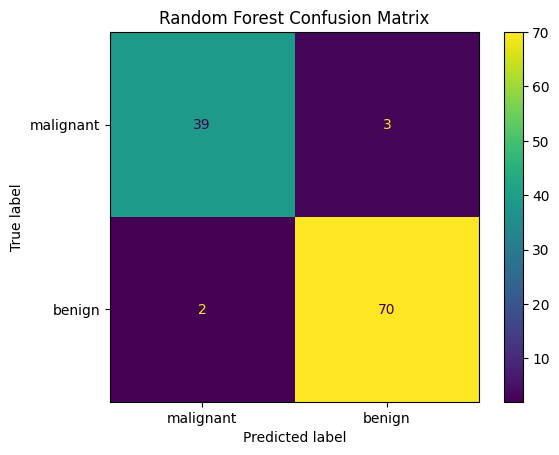

In [8]:
# Generate confusion matrix

cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm)

# Display confusion matrix graphically
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=data.target_names
)

disp.plot()
plt.title("Random Forest Confusion Matrix")
plt.show()

In [9]:
# Extract feature importance from Random Forest

feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_model.feature_importances_
})

# Sort features by importance
feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

# Display top 10 features
print("Top 10 Important Features:")
display(feature_importance.head(10))

Top 10 Important Features:


,Feature,Importance
23,worst area,0.140016
27,worst concave points,0.129530
20,worst radius,0.097696
7,mean concave points,0.090885
22,worst perimeter,0.072226
2,mean perimeter,0.069574
0,mean radius,0.068676
6,mean concavity,0.057638
3,mean area,0.049172
26,worst concavity,0.034340


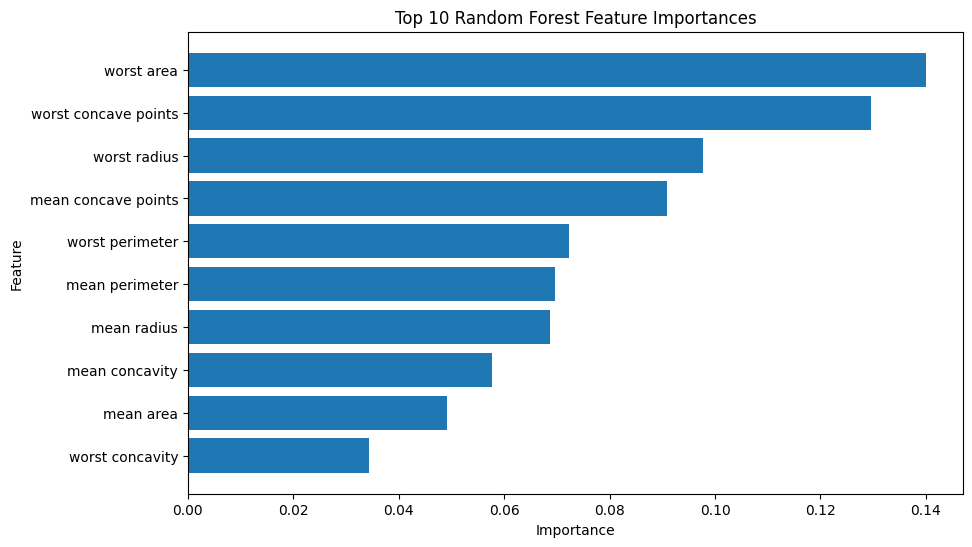

In [10]:
# Select top 10 important features

top_features = feature_importance.head(10)

plt.figure(figsize=(10, 6))

plt.barh(
    top_features["Feature"],
    top_features["Importance"]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Top 10 Random Forest Feature Importances")

plt.gca().invert_yaxis()

plt.show()

In [11]:
# Define hyperparameter combinations

param_grid = {
    "n_estimators": [50, 100, 200],
    "max_depth": [None, 5, 10, 15],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [1, 2]
}

# Create Random Forest model
rf = RandomForestClassifier(
    random_state=42
)

# Grid Search with 5-fold cross validation
grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

# Train Grid Search
grid_search.fit(X_train, y_train)

print("Hyperparameter tuning completed!")

Hyperparameter tuning completed!


In [12]:
# Display best parameters

print("Best Parameters:")
print(grid_search.best_params_)

print("\nBest Cross-Validation Accuracy:")
print(grid_search.best_score_)

Best Parameters:
{'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}

Best Cross-Validation Accuracy:
0.9604395604395606


In [13]:
# Get the best Random Forest model

best_rf = grid_search.best_estimator_

# Make predictions
best_predictions = best_rf.predict(X_test)

# Calculate accuracy
best_accuracy = accuracy_score(
    y_test,
    best_predictions
)

print("Tuned Random Forest Accuracy:", best_accuracy)

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        best_predictions,
        target_names=data.target_names
    )
)

Tuned Random Forest Accuracy: 0.956140350877193

Classification Report:
              precision    recall  f1-score   support

   malignant       0.95      0.93      0.94        42
      benign       0.96      0.97      0.97        72

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114



In [14]:
# Compare the performance of both models

comparison = pd.DataFrame({
    "Model": [
        "Basic Random Forest",
        "Tuned Random Forest"
    ],
    "Accuracy": [
        accuracy,
        best_accuracy
    ]
})

display(comparison)

,Model,Accuracy
0,Basic Random Forest,0.95614
1,Tuned Random Forest,0.95614


In [15]:
# Extract feature importance from tuned Random Forest

tuned_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": best_rf.feature_importances_
})

# Sort by importance
tuned_importance = tuned_importance.sort_values(
    by="Importance",
    ascending=False
)

print("Top 10 Features from Tuned Random Forest:")

display(
    tuned_importance.head(10)
)

Top 10 Features from Tuned Random Forest:


,Feature,Importance
22,worst perimeter,0.133100
23,worst area,0.128052
27,worst concave points,0.108107
7,mean concave points,0.094414
20,worst radius,0.090639
0,mean radius,0.058662
2,mean perimeter,0.055242
3,mean area,0.049938
6,mean concavity,0.046207
26,worst concavity,0.035357


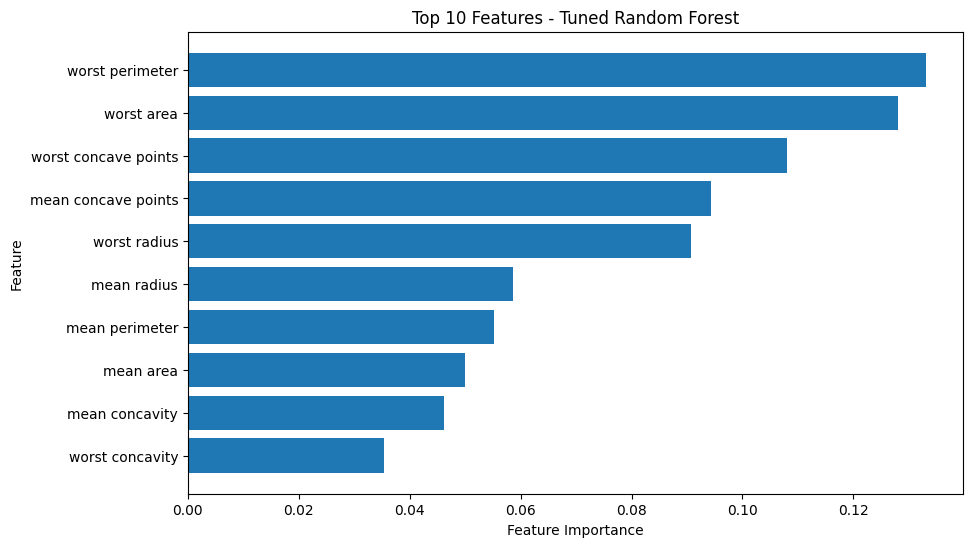

In [16]:
# Plot top 10 important features

top_tuned_features = tuned_importance.head(10)

plt.figure(figsize=(10, 6))

plt.barh(
    top_tuned_features["Feature"],
    top_tuned_features["Importance"]
)

plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.title("Top 10 Features - Tuned Random Forest")

plt.gca().invert_yaxis()

plt.show()

In [17]:
# Set MLflow experiment
mlflow.set_experiment("Random_Forest_Task")

# Get best parameters
best_params = grid_search.best_params_

# Start MLflow run
with mlflow.start_run():

    # Log hyperparameters
    mlflow.log_params(best_params)

    # Log model accuracy
    mlflow.log_metric("accuracy", best_accuracy)

    # Log cross-validation score
    mlflow.log_metric(
        "cross_validation_accuracy",
        grid_search.best_score_
    )

    # Log the trained model
    mlflow.sklearn.log_model(
        best_rf,
        "random_forest_model"
    )

    print("MLflow experiment logged successfully!")
    print("Accuracy:", best_accuracy)

2026/08/11 18:02:02 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/08/11 18:02:02 INFO mlflow.store.db.utils: Updating database tables
2026/08/11 18:02:06 INFO mlflow.tracking.fluent: Experiment with name 'Random_Forest_Task' does not exist. Creating a new experiment.
2026/08/11 18:02:06 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


MLflow experiment logged successfully!
Accuracy: 0.956140350877193


In [18]:
# Save feature importance results to CSV

tuned_importance.to_csv(
    "random_forest_feature_importance.csv",
    index=False
)

print("Feature importance saved successfully!")

Feature importance saved successfully!


In [19]:
# Basic tests for the trained model

assert X_train.shape[0] > 0
assert X_test.shape[0] > 0

assert len(best_predictions) == len(y_test)

assert 0 <= best_accuracy <= 1

assert len(tuned_importance) == X.shape[1]

print("All tests passed successfully!")

All tests passed successfully!


In [20]:
print("=" * 60)
print("RANDOM FOREST TASK - FINAL RESULTS")
print("=" * 60)

print("\nDataset:")
print("Breast Cancer Dataset")

print("\nNumber of Features:")
print(X.shape[1])

print("\nTraining Samples:")
print(X_train.shape[0])

print("\nTesting Samples:")
print(X_test.shape[0])

print("\nBasic Random Forest Accuracy:")
print(round(accuracy, 4))

print("\nTuned Random Forest Accuracy:")
print(round(best_accuracy, 4))

print("\nBest Parameters:")
for parameter, value in best_params.items():
    print(f"{parameter}: {value}")

print("\nTop 5 Important Features:")
display(tuned_importance.head(5))

print("=" * 60)

RANDOM FOREST TASK - FINAL RESULTS

Dataset:
Breast Cancer Dataset

Number of Features:
30

Training Samples:
455

Testing Samples:
114

Basic Random Forest Accuracy:
0.9561

Tuned Random Forest Accuracy:
0.9561

Best Parameters:
max_depth: None
min_samples_leaf: 1
min_samples_split: 2
n_estimators: 200

Top 5 Important Features:


,Feature,Importance
22,worst perimeter,0.133100
23,worst area,0.128052
27,worst concave points,0.108107
7,mean concave points,0.094414
20,worst radius,0.090639
